<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Stacked Charts**


Estimated time needed: **45** minutes


In this lab, you will focus on visualizing data specifically using stacked charts. You will use SQL queries to extract the necessary data and apply stacked charts to analyze the composition and comparison within the data.


## Objectives


In this lab, you will perform the following:


- Visualize the composition of data using stacked charts.

- Compare multiple variables across different categories using stacked charts.

- Analyze trends within stacked chart visualizations.


## Setup: Downloading and Loading the Data
**Install the libraries**


**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



### Step 1: Download the dataset


In [71]:
# https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

### Step 2: Import necessary libraries and load the dataset


In [72]:
import pandas as pd
import matplotlib.pyplot as plt

### Load the data


In [73]:
df = pd.read_csv("survey_data.csv")

### Display the first few rows of the data to understand its structure


In [74]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Stacked Chart for Composition of Job Satisfaction Across Age Groups


##### 1. Stacked Chart of Median `JobSatPoints_6` and `JobSatPoints_7` for Different Age Groups


Visualize the composition of job satisfaction scores (`JobSatPoints_6` and `JobSatPoints_7`) across various age groups. This will help in understanding the breakdown of satisfaction levels across different demographics.



In [75]:
##Write your code here
df_js = df[['Age', 'JobSatPoints_6', 'JobSatPoints_7']].dropna()

median_js_age = (
    df_js
    .groupby('Age')[['JobSatPoints_6', 'JobSatPoints_7']]
    .median()
    .sort_index()
)

median_js_age

,JobSatPoints_6,JobSatPoints_7
Age,,
18-24 years old,15.0,20.0
25-34 years old,20.0,15.0
35-44 years old,20.0,15.0
45-54 years old,20.0,15.0
55-64 years old,20.0,20.0
65 years or older,20.0,15.0
Prefer not to say,10.0,7.0
Under 18 years old,1.5,5.0


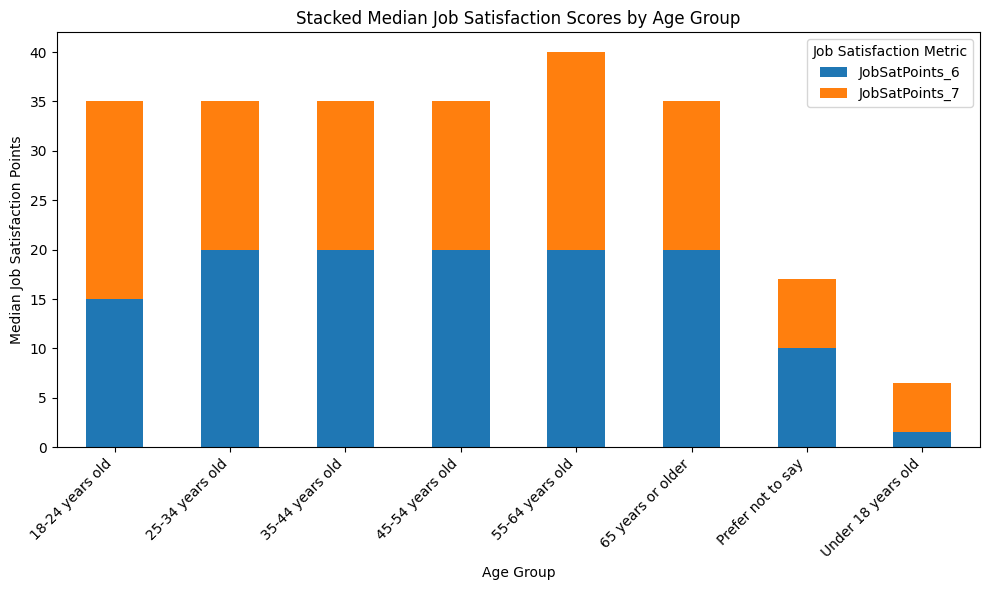

In [76]:
median_js_age.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title('Stacked Median Job Satisfaction Scores by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Median Job Satisfaction Points')
plt.legend(title='Job Satisfaction Metric')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

The stacked bar chart displays the median job satisfaction scores (JobSatPoints_6 and JobSatPoints_7) across different age groups.
Each bar represents an age group, while the stacked segments show how the two satisfaction components contribute to overall job satisfaction.
Trends across age groups indicate whether satisfaction increases, decreases, or remains stable with age. Differences in segment sizes highlight which satisfaction dimension contributes more strongly within each demographic.

##### Stacked Chart of `JobSatPoints_6` and `JobSatPoints_7` for Employment Status


Create a stacked chart to compare job satisfaction (`JobSatPoints_6` and `JobSatPoints_7`) across different employment statuses. This will show how satisfaction varies by employment type.


In [77]:
##Write your code here
df_js_emp = df[['Employment', 'JobSatPoints_6', 'JobSatPoints_7']].dropna()

df_js_emp['Employment'] = df_js_emp['Employment'].str.split(';')
df_js_emp = df_js_emp.explode('Employment')

In [78]:
median_js_emp = (
    df_js_emp
    .groupby('Employment')[['JobSatPoints_6', 'JobSatPoints_7']]
    .median()
    .sort_values(by='JobSatPoints_6', ascending=False)
)
median_js_emp

,JobSatPoints_6,JobSatPoints_7
Employment,,
"Employed, full-time",20.0,15.0
"Employed, part-time",15.0,15.0
"Independent contractor, freelancer, or self-employed",15.0,15.0
"Student, part-time",15.0,20.0
"Not employed, and not looking for work",10.0,10.0
"Not employed, but looking for work",10.0,10.0
Retired,10.0,11.0
"Student, full-time",10.0,15.0


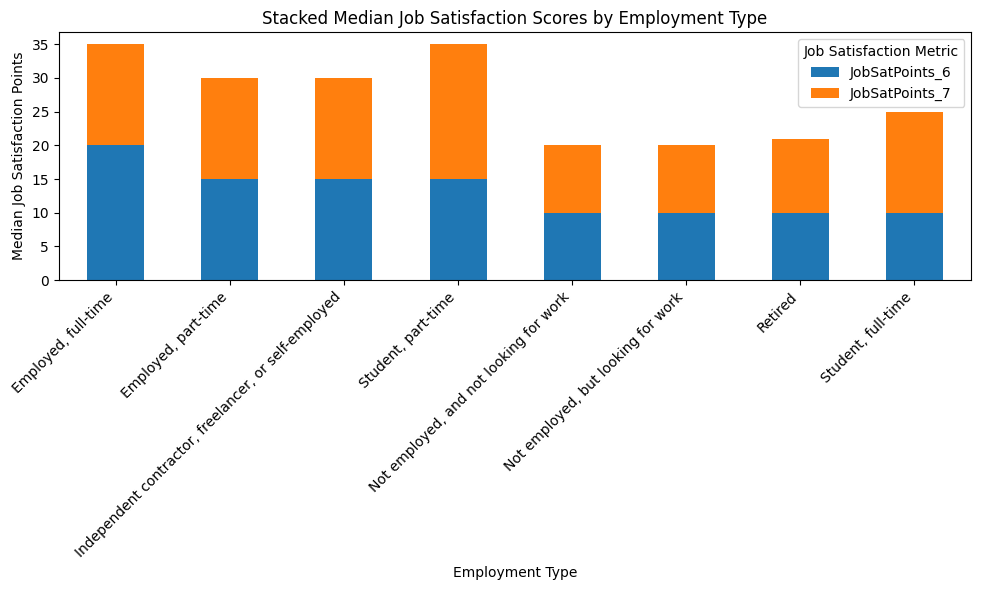

In [79]:
median_js_emp.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title('Stacked Median Job Satisfaction Scores by Employment Type')
plt.xlabel('Employment Type')
plt.ylabel('Median Job Satisfaction Points')
plt.legend(title='Job Satisfaction Metric')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

The stacked bar chart compares job satisfaction scores (JobSatPoints_6 and JobSatPoints_7) across different employment statuses.
Full-time employed respondents generally show higher combined satisfaction scores, while students and unemployed respondents exhibit lower overall satisfaction.
The relative size of each stacked segment highlights how different satisfaction components contribute to overall job satisfaction within each employment type.

### Task 2: Stacked Chart for Compensation and Job Satisfaction by Age Group


##### This stacked chart visualizes the composition of compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) specifically for respondents aged 30-35.


In [80]:
df['Age'].unique()

array(['Under 18 years old', '35-44 years old', '45-54 years old',
       '18-24 years old', '25-34 years old', '55-64 years old',
       'Prefer not to say', '65 years or older'], dtype=object)

In [81]:
##Write your code here
df_comp_sat = df[['Age', 'ConvertedCompYearly', 'JobSatPoints_6']].dropna()

In [82]:
df_25_34 = df_comp_sat[df_comp_sat['Age'] == '25-34 years old']

In [83]:
# Normalization

median_values = df_25_34[['ConvertedCompYearly', 'JobSatPoints_6']].median()
median_values

ConvertedCompYearly    59872.0
JobSatPoints_6            20.0
dtype: float64

In [84]:
normalized = median_values / median_values.sum()

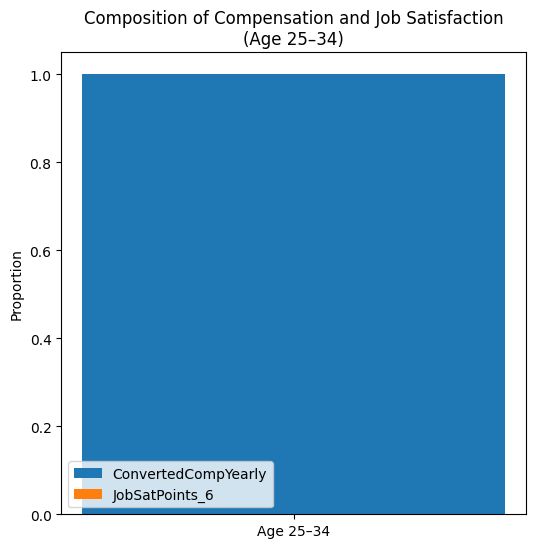

In [85]:
plt.figure(figsize=(6, 6))

plt.bar(
    ['Age 25–34'],
    normalized['ConvertedCompYearly'],
    label='ConvertedCompYearly'
)

plt.bar(
    ['Age 25–34'],
    normalized['JobSatPoints_6'],
    bottom=normalized['ConvertedCompYearly'],
    label='JobSatPoints_6'
)

plt.title('Composition of Compensation and Job Satisfaction\n(Age 25–34)')
plt.ylabel('Proportion')
plt.legend()

Due to the categorical nature of the Age variable, respondents aged 25–34 years were used as a proxy for the 30–35 age range.

The stacked chart shows the relative contribution of median yearly compensation and job satisfaction for this age group after normalization. While compensation dominates numerically, job satisfaction still represents an important qualitative component of overall work experience.

##### Stacked Chart of Median Compensation and Job Satisfaction Across Age Group


Compare the median compensation and job satisfaction metrics across different age groups. This helps visualize how compensation and satisfaction levels differ by age.


In [86]:
##Write your code here
df_age_comp = df[['Age', 'ConvertedCompYearly', 'JobSatPoints_6']].dropna()

median_age_metrics = df_age_comp.groupby('Age')[['ConvertedCompYearly', 'JobSatPoints_6']].median()

age_order = ['Under 18 years old', '18-24 years old', '25-34 years old', 
             '35-44 years old', '45-54 years old', '55-64 years old', 
             '65 years or older']
median_age_metrics = median_age_metrics.reindex(age_order)
median_age_metrics

,ConvertedCompYearly,JobSatPoints_6
Age,,
Under 18 years old,8661.0,10.0
18-24 years old,25735.0,20.0
25-34 years old,59872.0,20.0
35-44 years old,85925.0,20.0
45-54 years old,100900.5,20.0
55-64 years old,119189.5,20.0
65 years or older,121668.0,20.0


In [87]:
normalized_metrics = median_age_metrics.div(median_age_metrics.sum(axis=1), axis=0)
normalized_metrics

,ConvertedCompYearly,JobSatPoints_6
Age,,
Under 18 years old,0.998847,0.001153
18-24 years old,0.999223,0.000777
25-34 years old,0.999666,0.000334
35-44 years old,0.999767,0.000233
45-54 years old,0.999802,0.000198
55-64 years old,0.999832,0.000168
65 years or older,0.999836,0.000164


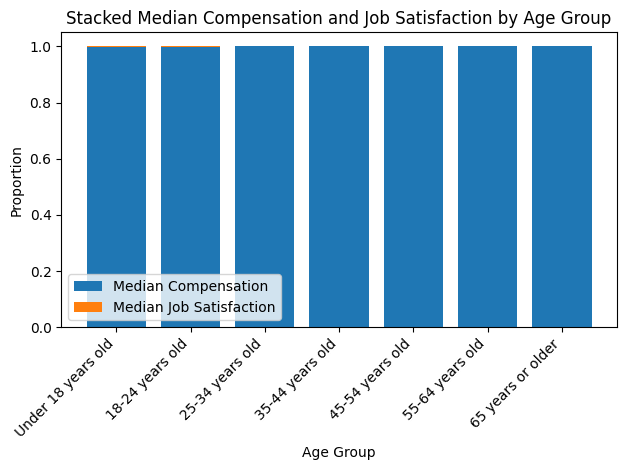

In [88]:
plt.bar(
    normalized_metrics.index,
    normalized_metrics['ConvertedCompYearly'],
    label='Median Compensation'
)

plt.bar(
    normalized_metrics.index,
    normalized_metrics['JobSatPoints_6'],
    bottom=normalized_metrics['ConvertedCompYearly'],
    label='Median Job Satisfaction'
)

plt.title('Stacked Median Compensation and Job Satisfaction by Age Group')
plt.ylabel('Proportion')
plt.xlabel('Age Group')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()

- The chart shows how the relative contribution of median compensation and median job satisfaction varies across age groups.
- Younger respondents tend to have lower compensation, but job satisfaction contributes a larger relative portion.
- Older age groups have higher compensation, which dominates the stack, but job satisfaction remains an important component.
- Normalization allows both metrics to be visualized together without being misleading due to scale differences.

### Task 3: Comparing Data Using Stacked Charts


##### 1. Stacked Chart of Preferred Databases by Age Group




Visualize the top databases that respondents from different age groups wish to learn. Create a stacked chart to show the proportion of each database in each age group.


In [89]:
##Write your code here
df['DatabaseWantToWorkWith'].unique()

array([nan, 'PostgreSQL', 'Firebase Realtime Database', ...,
       'Cassandra;Firebase Realtime Database;MariaDB;Microsoft Access;MongoDB;MySQL;PostgreSQL;Redis',
       'MySQL;Presto;TiDB',
       'BigQuery;Cassandra;Databricks SQL;DuckDB;Elasticsearch;Firebase Realtime Database;Microsoft SQL Server;MongoDB;MySQL;PostgreSQL;Redis;Snowflake;SQLite;Supabase'],
      shape=(8479,), dtype=object)

In [90]:
df_db_age = df[['Age', 'DatabaseWantToWorkWith']].dropna()

# Splitting multiple database entries into separate rows
df_db_age = df_db_age.assign(Database=df_db_age['DatabaseWantToWorkWith'].str.split(';')).explode('Database')

#stripping extra whitespace
df_db_age['Database'] = df_db_age['Database'].str.strip()

In [91]:
top5_dbs = df_db_age['Database'].value_counts().head(5).index

df_db_age_top = df_db_age[df_db_age['Database'].isin(top5_dbs)]

In [92]:
db_age_counts = (
    df_db_age_top.groupby(['Age', 'Database'])
    .size()
    .unstack(fill_value=0)  # making a table of Age × Database
)

In [93]:
db_age_props = db_age_counts.div(db_age_counts.sum(axis=1), axis=0)

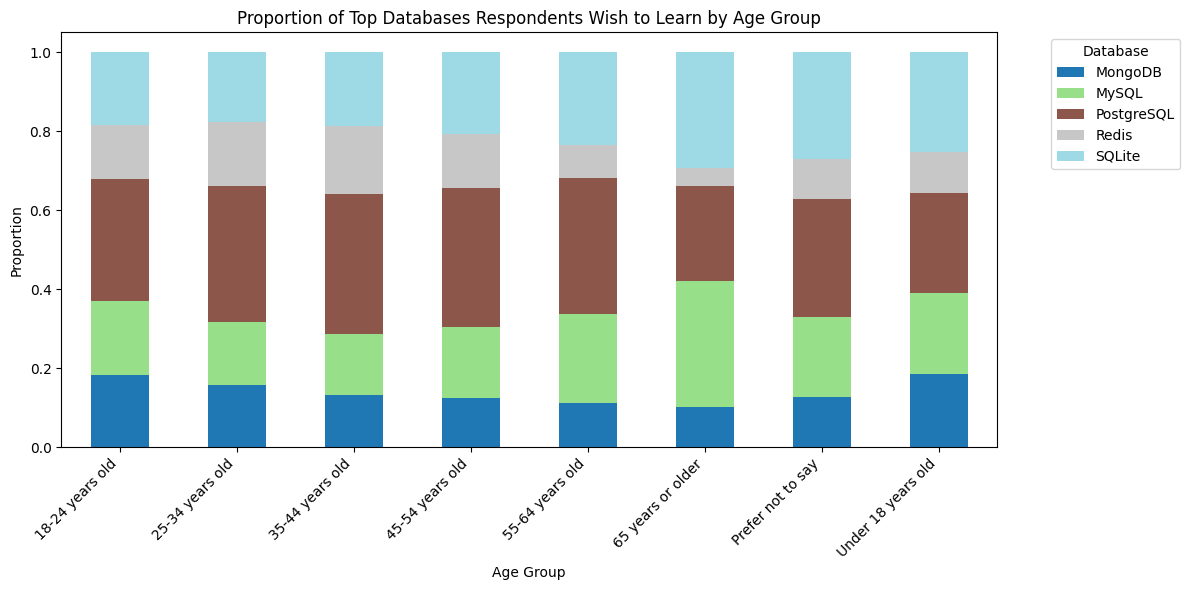

In [94]:
db_age_props.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    colormap='tab20'
)

plt.title('Proportion of Top Databases Respondents Wish to Learn by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Proportion')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Database', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

The stacked bar chart shows how the top 5 databases are desired across age groups. For instance, PostgreSQL dominate across all age ranges, but younger respondents may prefer newer technologies like MongoDB more than older age groups. This visualization helps understand which databases are popular among different experience levels.

##### 2. Stacked Chart of Employment Type by Job Satisfaction


Analyze the distribution of employment types within each job satisfaction level using a stacked chart. This will provide insights into how employment types are distributed across various satisfaction ratings.


In [95]:
##Write your code here
df_emp_js = df[['Employment', 'JobSatPoints_6']].dropna()

df_emp_js['EmploymentPrimary'] = df_emp_js['Employment'].str.split(';').str[0]

In [96]:
top5 = df_emp_js['JobSatPoints_6'].value_counts().head(5).index

df_db_top = df_emp_js[df_emp_js['JobSatPoints_6'].isin(top5)]

In [97]:
emp_js_counts = (
    df_db_top
    .groupby(['EmploymentPrimary', 'JobSatPoints_6'])
    .size()
    .unstack(fill_value=0)
)

In [98]:
emp_js_props = emp_js_counts.div(emp_js_counts.sum(axis=1), axis=0)

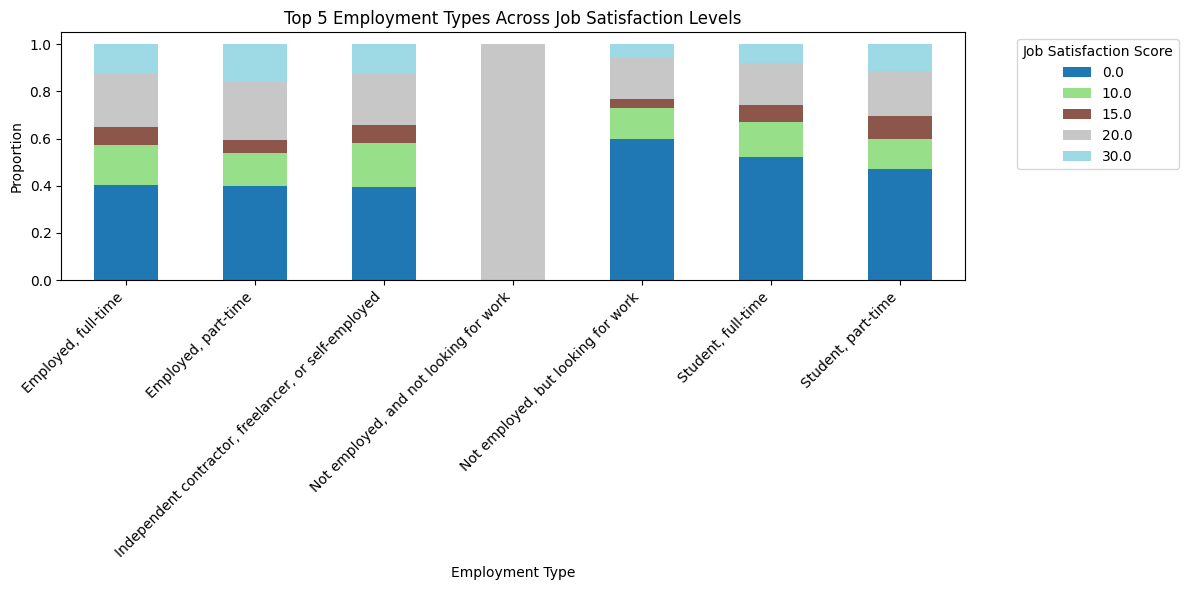

In [99]:
emp_js_props.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    colormap='tab20'
)

plt.title('Top 5 Employment Types Across Job Satisfaction Levels')
plt.xlabel('Employment Type')
plt.ylabel('Proportion')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Job Satisfaction Score', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

The stacked chart shows how employment types are distributed across job satisfaction levels.
Full-time employees are more frequent in higher satisfaction scores, whereas part-time or student respondents are more common at lower satisfaction levels. This highlights which employment groups are more likely to report high job satisfaction.

### Task 4: Exploring Technology Preferences Using Stacked Charts


##### 1. Stacked Chart for Preferred Programming Languages by Age Group


Analyze how programming language preferences (`LanguageAdmired`) vary across age groups.

In [100]:
##Write your code here
df['LanguageAdmired'].unique()

array([nan,
       'Bash/Shell (all shells);Go;HTML/CSS;Java;JavaScript;Python;TypeScript',
       'C#', ..., 'Elixir;Lua;Python;Ruby;SQL',
       'Bash/Shell (all shells);C;C++;HTML/CSS;Java;JavaScript;PowerShell;Rust;Solidity;SQL;TypeScript;VBA;Visual Basic (.Net)',
       'Bash/Shell (all shells);C#;HTML/CSS;Java;JavaScript;Objective-C;Python;SQL;Swift;TypeScript'],
      shape=(12336,), dtype=object)

In [101]:
df_lang_age = df[['Age', 'LanguageAdmired']].dropna()
df_lang_age['Language'] = df_lang_age['LanguageAdmired'].str.split(';').explode('Language')
df_lang_age['Language'] = df_lang_age['Language'].str.strip()
df_lang_age

,Age,LanguageAdmired,Language
1,35-44 years old,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Go
2,45-54 years old,C#,HTML/CSS
3,18-24 years old,HTML/CSS;Java;JavaScript;PowerShell;Python;SQL...,Java
4,18-24 years old,C++;HTML/CSS;JavaScript;Lua;Python,JavaScript
5,Under 18 years old,Bash/Shell (all shells);HTML/CSS;Java;JavaScri...,Python
...,...,...,...
65409,35-44 years old,HTML/CSS;JavaScript;PowerShell,Bash/Shell (all shells)
65427,25-34 years old,Python;SQL,SQL
65431,45-54 years old,Bash/Shell (all shells);C#;HTML/CSS;Java;JavaS...,Elixir
65435,18-24 years old,Rust;SQL,Rust


In [102]:
top5_langs = df_lang_age['Language'].value_counts().head(5).index

df_lang_age_top = df_lang_age[df_lang_age['Language'].isin(top5_langs)]

In [103]:
lang_age_counts = (
    df_lang_age_top.groupby(['Age', 'Language'])
    .size()
    .unstack(fill_value=0) 
)

In [104]:
lang_age_props = lang_age_counts.div(lang_age_counts.sum(axis=1), axis=0)

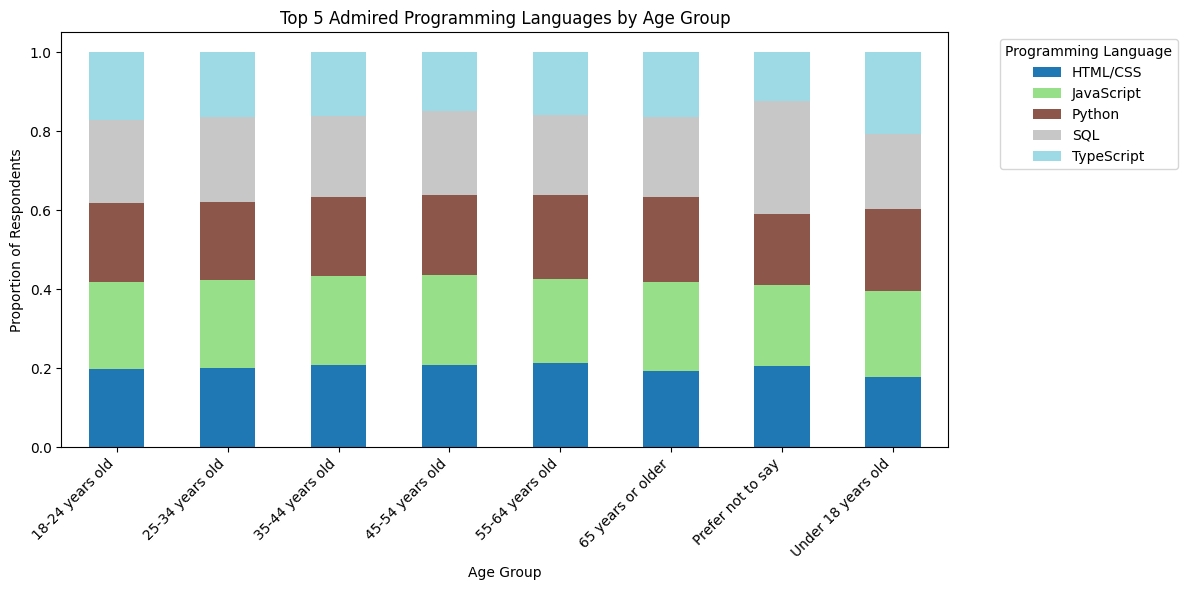

In [105]:
lang_age_props.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    colormap='tab20'
)

plt.title('Top 5 Admired Programming Languages by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Proportion of Respondents')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Programming Language', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

The stacked chart shows how respondents’ favorite programming languages vary across age groups.
For example, Python and JavaScript are consistently popular across all ages, while older age groups might favor C# or Java slightly more.
This helps identify trends in language popularity by experience/age demographic.

##### 2. Stacked Chart for Technology Adoption by Employment Type


Explore how admired platforms (`PlatformAdmired`) differ across employment types (e.g., full-time, freelance)


In [109]:
##Write your code here
df['PlatformAdmired'].unique()

array([nan, 'Amazon Web Services (AWS);Heroku;Netlify', 'Google Cloud',
       ..., 'Firebase;Microsoft Azure;Netlify;Vercel',
       'Amazon Web Services (AWS);Google Cloud;Heroku;Linode, now Akamai;Vercel',
       'PythonAnywhere;Render;Vercel'], shape=(2557,), dtype=object)

In [110]:
df_platform = df[['Employment', 'PlatformAdmired']].dropna()

df_platform = (
    df_platform
    .assign(Platform=df_platform['PlatformAdmired'].str.split(';'))
    .explode('Platform')
)

In [111]:
df_platform['Platform'] = df_platform['Platform'].str.strip()
df_platform['EmploymentPrimary'] = df_platform['Employment'].str.split(';').str[0]

In [112]:
top5_platforms = df_platform['Platform'].value_counts().head(5).index
df_platform_top = df_platform[df_platform['Platform'].isin(top5_platforms)]

In [113]:
platform_counts = (
    df_platform_top.groupby(['EmploymentPrimary', 'Platform'])
    .size()
    .unstack(fill_value=0)
)

In [114]:
platform_props = platform_counts.div(platform_counts.sum(axis=1), axis=0)

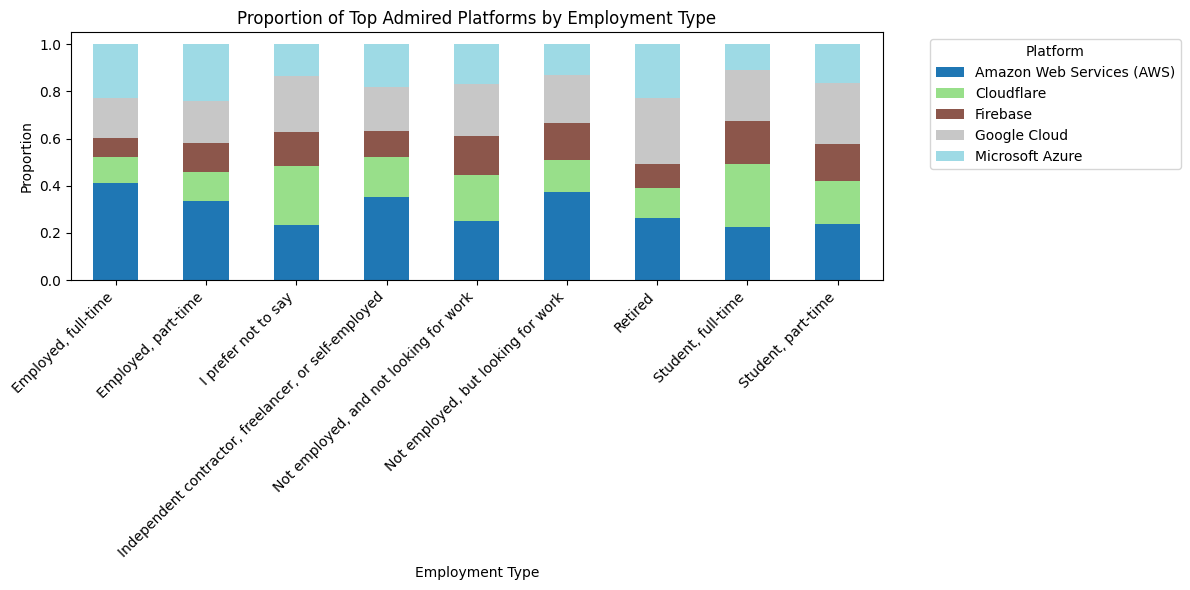

In [118]:
platform_props.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    colormap='tab20'
)

plt.title('Proportion of Top Admired Platforms by Employment Type')
plt.xlabel('Employment Type')
plt.ylabel('Proportion')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Platform', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

The stacked chart illustrates how admiration for major cloud and hosting platforms varies by employment type. Full-time employees show a strong preference for enterprise platforms such as AWS and Azure, while freelancers and students tend to favor lightweight deployment platforms like Vercel and Netlify. This highlights differences in technology adoption driven by work context and infrastructure needs.

### Final Step: Review


In this lab, you focused on using stacked charts to understand the composition and comparison within the dataset. Stacked charts provided insights into job satisfaction, compensation, and preferred databases across age groups and employment types.


## Summary


After completing this lab, you will be able to:

- Use stacked charts to analyze the composition of data across categories, such as job satisfaction and compensation by age group.

- Compare data across different dimensions using stacked charts, enhancing your ability to communicate complex relationships in the data.

- Visualize distributions across multiple categories, such as employment type by satisfaction, to gain a deeper understanding of patterns within the dataset.


## Author:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
